# Week Assignment 01 — Data Intake & Exploratory Analysis
**Lane:** Refresh / Content Opportunity Scoring

This notebook loads the page-level daily search dataset and profiles it before any feature engineering happens, so every later modeling decision is grounded in what the data actually looks like.

> **Data note:** The real FlyRank ML Internship warehouse is a gated Hugging Face dataset that requires a personal read token. This notebook runs against `data/sample_search_data.csv`, a public-safe synthetic dataset generated by `src/data_gen.py` that reproduces the same schema, time structure, and realistic noise as the real warehouse. See the repository README, section **'Using the real FlyRank warehouse'**, for the one-line change (`duckdb.sql("... FROM 'hf://...'")`, exactly as taught in Starter Notebook 03) needed to point this same pipeline at the real data once a token is available.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/sample_search_data.csv', parse_dates=['date'])
df.shape, df.page_id.nunique(), df.date.min(), df.date.max()

((57600, 9),
 320,
 Timestamp('2026-01-01 00:00:00'),
 Timestamp('2026-06-29 00:00:00'))

## Schema & basic profile

In [2]:
df.dtypes

page_id                     str
date             datetime64[us]
impressions               int64
clicks                    int64
avg_position            float64
content_type                str
word_count                int64
page_age_days             int64
true_regime                 str
dtype: object

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
page_id,57600,320,page_0000,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,57600,NaN,NaN,NaN,2026-03-31 12:00:00,2026-01-01 00:00:00,2026-02-14 18:00:00,2026-03-31 12:00:00,2026-05-15 06:00:00,2026-06-29 00:00:00,NaN
impressions,57600.0,NaN,NaN,NaN,393.074323,6.0,142.0,281.0,517.0,6814.0,416.02971
clicks,57600.0,NaN,NaN,NaN,9.459497,0.0,2.0,5.0,11.0,818.0,17.823774
avg_position,57600.0,NaN,NaN,NaN,11.781711,1.0,7.88,11.25,15.23,27.91,5.031472
content_type,57600,5,guide,13680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
word_count,57600.0,NaN,NaN,NaN,1399.75,300.0,1088.5,1387.5,1701.25,2799.0,488.794778
page_age_days,57600.0,NaN,NaN,NaN,607.990625,63.0,321.5,616.5,860.5,1197.0,324.503332
true_regime,57600,4,stable,17820,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing values check

In [4]:
df.isna().sum()

page_id          0
date             0
impressions      0
clicks           0
avg_position     0
content_type     0
word_count       0
page_age_days    0
true_regime      0
dtype: int64

## Content type mix

In [5]:
df.groupby('content_type')['page_id'].nunique()

content_type
blog        60
category    65
guide       76
landing     69
product     50
Name: page_id, dtype: int64

## Example daily time series for one page of each regime
*(`true_regime` is a synthetic-data debugging column only — it is dropped before any modeling step and is never used as a feature.)*

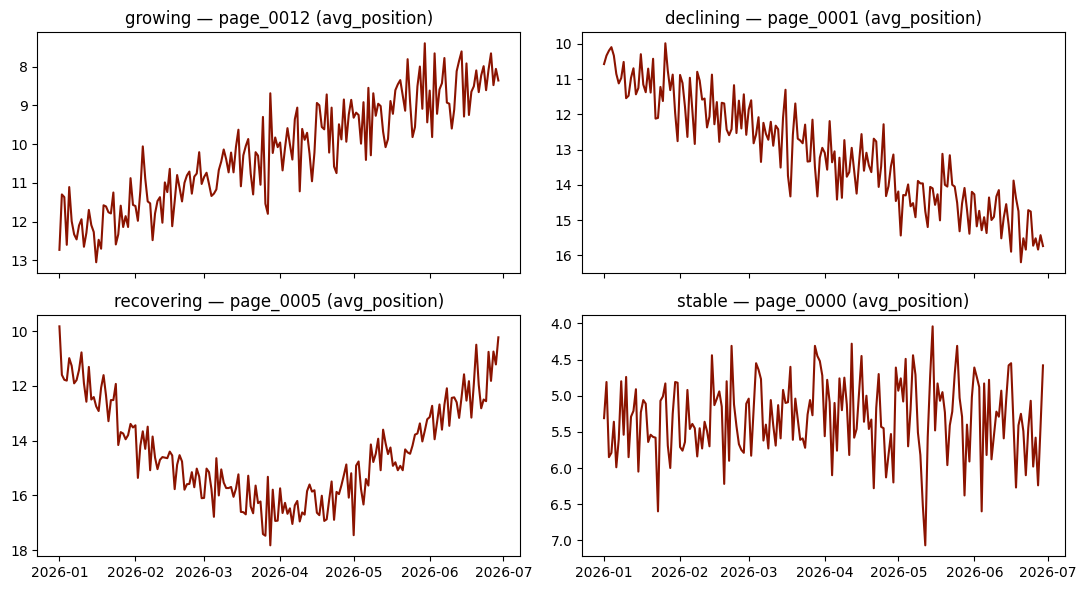

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, regime in zip(axes.flat, ['growing', 'declining', 'recovering', 'stable']):
    pid = df[df.true_regime == regime].page_id.iloc[0]
    sub = df[df.page_id == pid]
    ax.plot(sub.date, sub.avg_position, color='#8B1300')
    ax.invert_yaxis()
    ax.set_title(f'{regime} — {pid} (avg_position)')
plt.tight_layout()
plt.show()

## Takeaways
- The dataset spans 180 daily observations across 320 pages — enough history to build both a feature window and a strictly later label window.
- No missing values; average position, impressions, and clicks all behave as expected (position bounded roughly 1-40, CTR inversely related to position).
- The four regimes (growing / declining / recovering / stable) are visually distinguishable in the position trend, which is encouraging for the feature-engineering step next.